### 1. Tăng độ tương phản sử dụng openCV

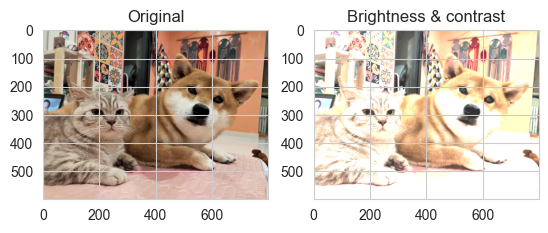

In [105]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from numpy.conftest import dtype

image = cv2. imread("dogcat.png")
image_rgb = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
# anh goc
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(image_rgb)

#thay doi do sang va do tuong phan
# g(x, y) = af(x, y) + B
alpha = 1.5
beta = 50

#thay doi do tuong phan su dung ham converScaleAbs()
image2 = cv2.convertScaleAbs(image_rgb, alpha=alpha, beta=beta)

plt.subplot(1, 2, 2)
plt.title("Brightness & contrast")
plt.imshow(image2)
plt.show()

### 2. Threshold

Gobal Threshold

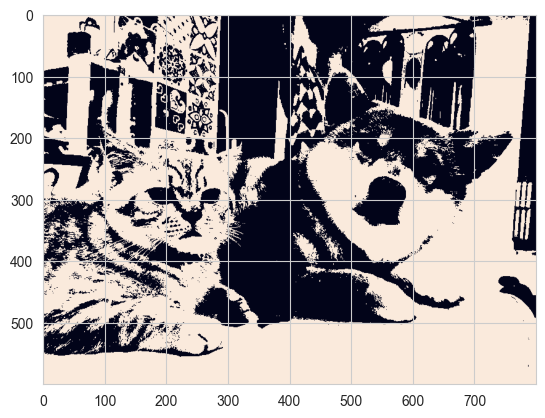

In [106]:
import cv2

img = cv2.imread("dogcat.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
gray_image = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray_image, 120, 255, cv2.THRESH_BINARY)

plt.imshow(thresh)

Adaptive Threshold

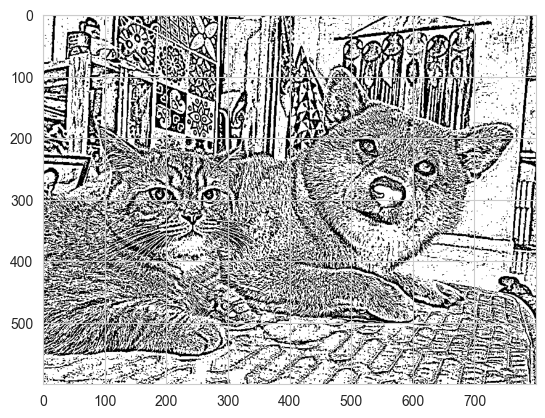

In [107]:
import cv2

img = cv2.imread("dogcat.png", 0) #grayscale luon

thresh = cv2.adaptiveThreshold(
            img,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            11, # kich thuoc vung
            2) # hang so tru

thresh_rgb = cv2.cvtColor(thresh, cv2.COLOR_RGB2BGR)

plt.imshow(thresh_rgb)

Otsu Threshold

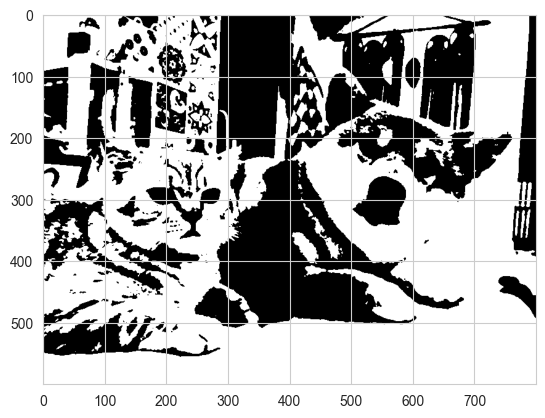

In [108]:
import cv2

img = cv2.imread("dogcat.png", 0)

# blur trước cho tốt hơn
blur = cv2.GaussianBlur(img, (5,5), 0)

_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

thresh_rgb = cv2.cvtColor(thresh, cv2.COLOR_RGB2BGR)

plt.imshow(thresh_rgb)

### 3. Morphological

In [109]:
def show(inv, out, operation):
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(inv, cmap="gray")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"{operation} Image")
    plt.imshow(out, cmap="gray")
    plt.axis('off')

Erosion

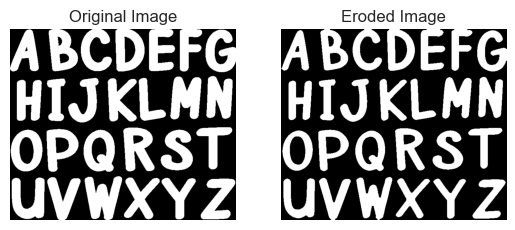

In [111]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("abc.png", 0) # anh xam

thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

k = np.ones((5, 5), np.uint8) # ma tran kernel 5 x 5
inv = cv2.bitwise_not(thresh)
out = cv2.erode(inv, k, 1)

show(inv, out, "Eroded")

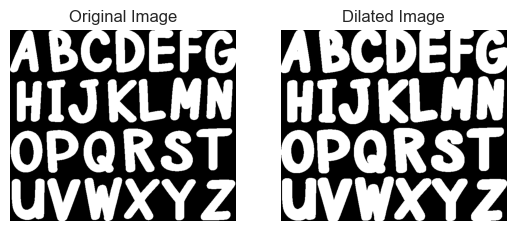

In [112]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("abc.png", 0) # anh xam

thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

k = np.ones((5, 5), np.uint8) # ma tran kernel 5 x 5
inv = cv2.bitwise_not(thresh)
out = cv2.dilate(inv, k, 1)

show(inv, out, "Dilated")


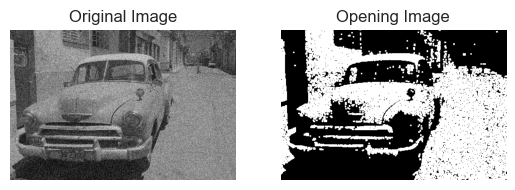

In [113]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("car.png", 0)  # Load grayscale
bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]  # Binarize

k = np.ones((3, 3), np.uint8)  # 3x3 kernel
opened = cv2.morphologyEx(bin, cv2.MORPH_OPEN, k)
show(img, opened, "Opening")

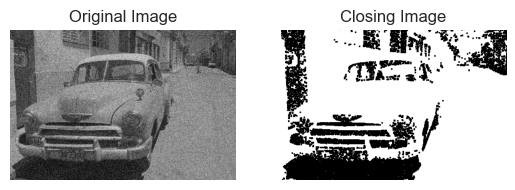

In [114]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("car.png", 0)  # Load grayscale
bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]  # Binarize

k = np.ones((3, 3), np.uint8)  # 3x3 kernel
opened = cv2.morphologyEx(bin, cv2.MORPH_CLOSE, k)
show(img, opened, "Closing")

### 4. Contour

(np.float64(-0.5), np.float64(659.5), np.float64(557.5), np.float64(-0.5))

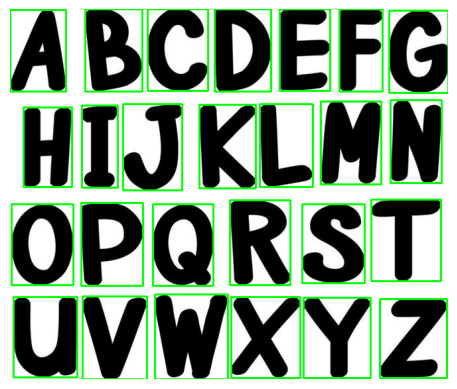

In [115]:
import cv2

img = cv2.imread("abc.png")


gray = cv2. cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
# tìm contour
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = img.copy()
characters = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)

    if w > 20 and h > 20:
        cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2)
        char = thresh[y:y+h, x:x+w]
        char = cv2.resize(char, (32, 32))
        characters.append(char)

plt.imshow(output)
plt.axis('off')


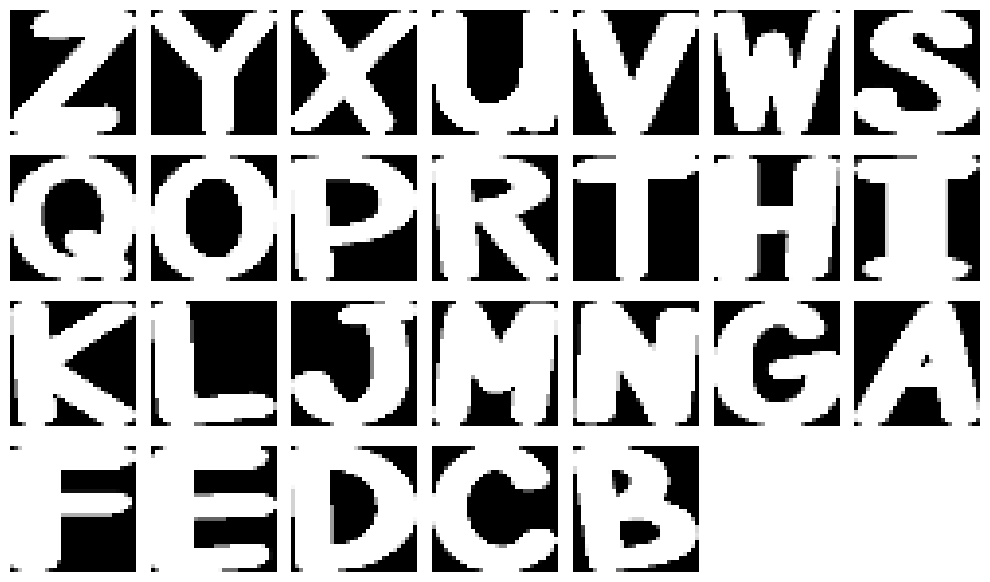

In [116]:
#crop ký tự

plt.figure(figsize=(10,6))

for i, char in enumerate(characters[:26]):
    plt.subplot(4, 7, i+1)
    plt.imshow(char, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

### 5. Deskew

Góc nghiêng: -90.0


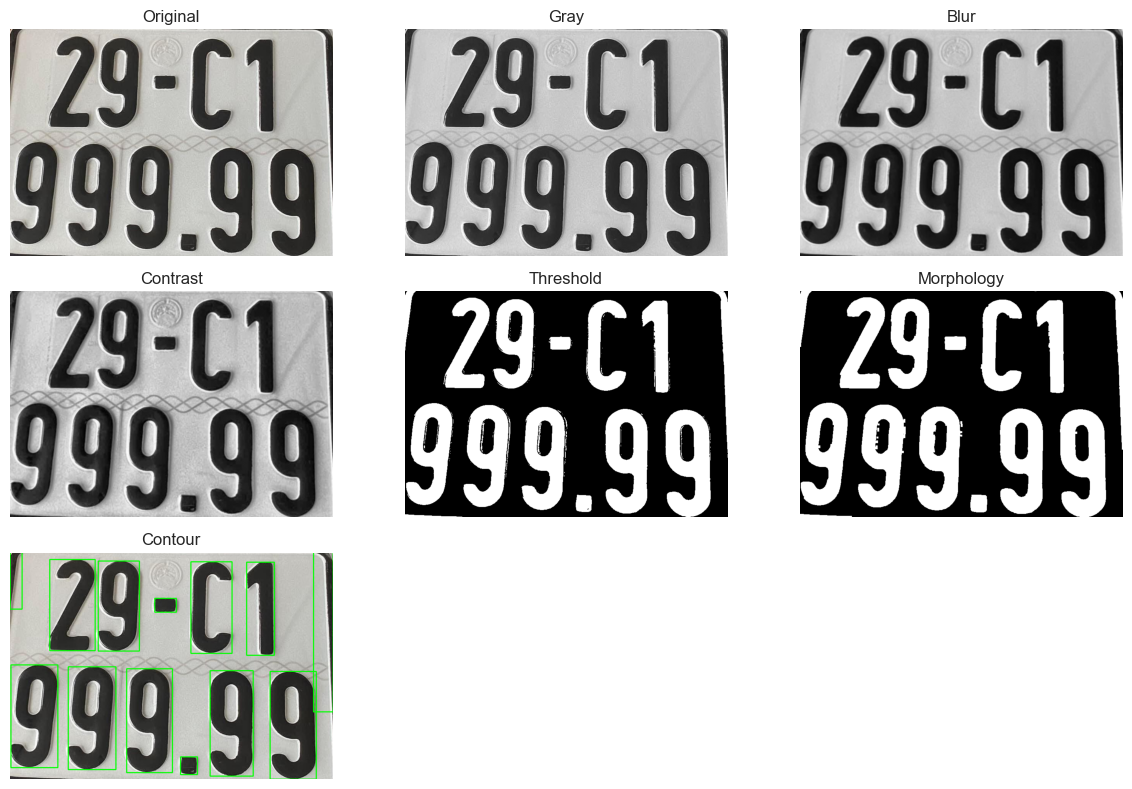

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc ảnh bất kỳ
img = cv2.imread("img_4.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Blur (giảm nhiễu)
blur = cv2.GaussianBlur(gray, (5,5), 0)
edged = cv2.Canny(blur, 30, 200)
# 4. Tăng tương phản (CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
contrast = clahe.apply(blur)

# 5. Threshold
_, thresh = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# 6. Morphology
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
morph = cv2.dilate(opening, kernel, iterations=1)

# 7. Contour
contours, _ = cv2.findContours(
    morph,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# vẽ contour
contour_img = img_rgb.copy()
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w > 20 and h > 20:
        cv2.rectangle(contour_img, (x,y), (x+w,y+h), (0,255,0), 2)

# =========================
# HIỂN THỊ
# =========================
titles = [
    "Original", "Gray", "Blur",
    "Contrast", "Threshold", "Morphology", "Contour"
]

images = [
    img_rgb, gray, blur,
    contrast, thresh, morph, contour_img
]

plt.figure(figsize=(12,8))

for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

#### 6. Nhận dạng ký tự sử dụng Tesseract

In [117]:
import cv2

import pytesseract
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [118]:
from PIL import Image
import pytesseract

# Load an image
img = Image.open('img_5.png')

# Extract text from image
text = pytesseract.image_to_string(img)

print(text)

In the age of digital transformation, extracting
information from images and scanned documents has
become a crucial task.



### 7. Ví dụ xử lý một ảnh bển số

#### Ảnh gốc

(np.float64(-0.5), np.float64(1535.5), np.float64(1184.5), np.float64(-0.5))

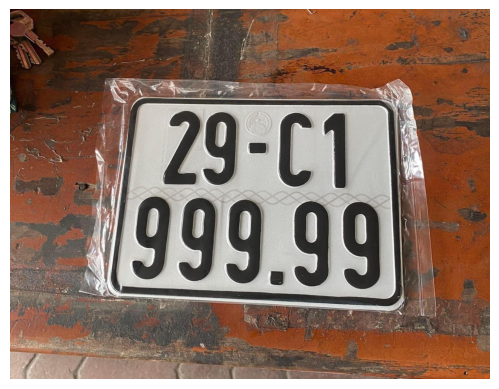

In [149]:
import cv2
import matplotlib.pyplot as plt

original = cv2.imread('img_3.png')
plt.imshow(cv2.cvtColor(original, cv2.COLOR_RGB2BGR))
plt.axis('off')

##### Ảnh gốc là một ảnh biển số khá rõ ràng, nhưng ảnh nằm hơi nghiêng và nền ảnh có nhiều nhiễu, nên cần có bước biến đôi thành ảnh phẳng và cắt nền, chỉ giữ lại khung biển số
##### 5.1 Các bước biến đổi

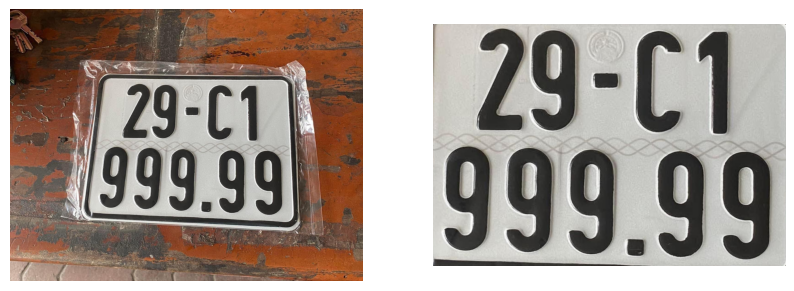

In [150]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract

#1. Đọc và tìm 4 góc của biển số
img = cv2.imread('img_3.png')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # chuyển sang ảnh xám
blur = cv2.bilateralFilter(gray, 11, 17, 17) # làm mịn anh

edged = cv2.Canny(blur, 30, 200) # phát hiện biên

cnts, _ = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) # tìm các contour
cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:10] # quan tâm đến 10 contour có diện tích lớn nhất, sắp xếp theo diện tích giảm dần

#tìm contour đầu tiên có đủ 4 điểm
screenCnt = None
for c in cnts:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)
    if len(approx) == 4:
        screenCnt = approx
        break

if screenCnt is not None:

    pts = screenCnt.reshape(4, 2)
    rect = np.zeros((4, 2), dtype="float32")

    # xác định tọa độ của bốn điểm
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)] # điểm trên-trái là điểm có tổng
    rect[2] = pts[np.argmax(s)] # điểm dưới-phải là điểm có tổng x + y lớn nhất
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]

    #tính độ dài các cạnh
    (tl, tr, br, bl) = rect
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2 + (tl[1] - bl[1]) ** 2))

    maxHeight = max(int(heightA), int(heightB))

    # tọa độ 4 điểm của hình chữ nhật tiêu chuẩn
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype="float32")

    # Ma trận biến đổi M
    M = cv2. getPerspectiveTransform(rect, dst)

    # Áp dụng biến đổi
    warped = cv2.warpPerspective(img, M, (maxWidth, maxHeight))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(warped, cv2.COLOR_RGB2BGR))
    plt.axis('off')

##### Sau khi đã cắt được vùng biển số và xoay thẳng ta có thể phân đoạn các kỹ tự dễ dàng và chính xác hơn

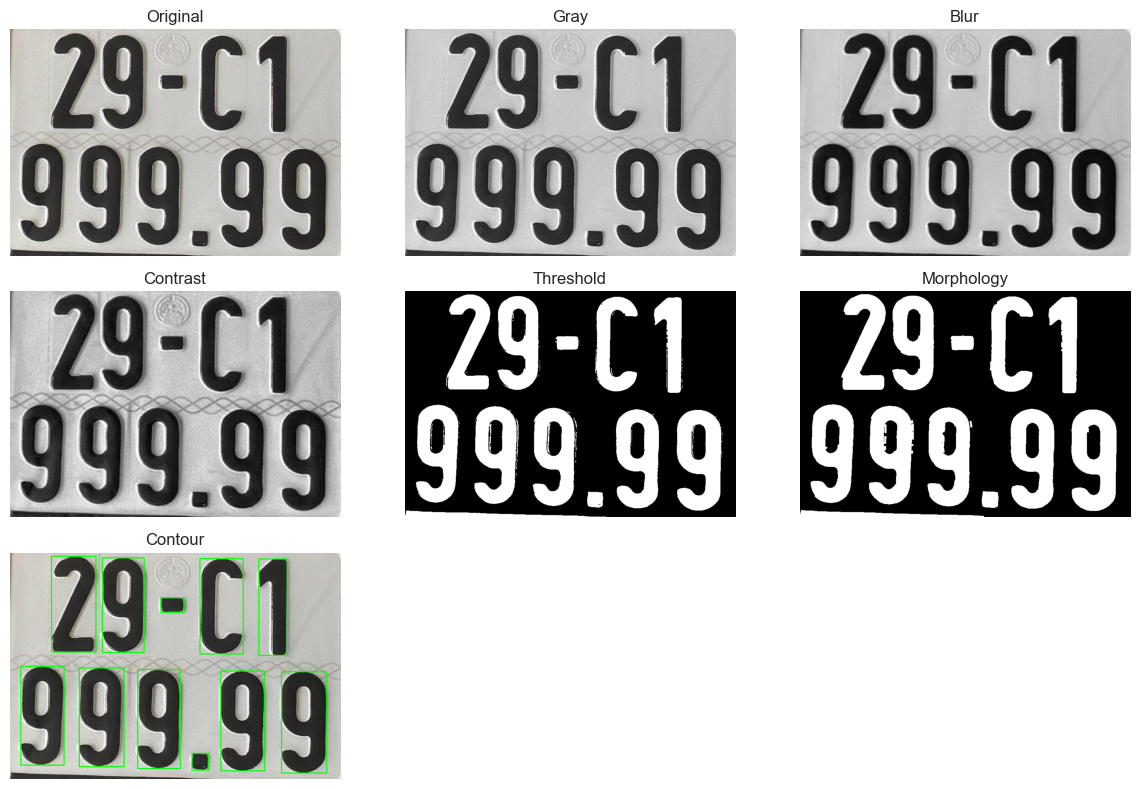

Kết quả:  QV42QSS


In [151]:
img_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

#Grayscale
gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

#Blur (giảm nhiễu)
blur = cv2.GaussianBlur(gray, (5,5), 0)
edged = cv2.Canny(blur, 30, 200)
# Tăng tương phản (CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
contrast = clahe.apply(blur)

#Threshold, sử dụng THRESH_BINARY_INV kết hợp THRESH_OTSU để biến đổi chữ đen -> trắng
_, thresh = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

#Morphology, loại bỏ nhiễu, làm dày kí tự
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
morph = cv2.dilate(opening, kernel, iterations=1)

#Contour
contours, _ = cv2.findContours(
    morph,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])
result = ""

#vẽ contour và đọc ký tự
contour_img = img_rgb.copy()
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w > 20 and h > 20:
        cv2.rectangle(contour_img, (x,y), (x+w,y+h), (0,255,0), 2)

        char = morph[y:y+h, x:x+w]

        char = cv2.resize(char, (50, 50))

        text = pytesseract.image_to_string(
            char,
            config='--psm 10 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
        )

        result += text.strip()

# hiện thị kết quả
titles = [
    "Original", "Gray", "Blur",
    "Contrast", "Threshold", "Morphology", "Contour"
]

images = [
    img_rgb, gray, blur,
    contrast, thresh, morph, contour_img
]

plt.figure(figsize=(12,8))

for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
print("Kết quả: ", result)